# Clase 05: Colas, FIFO y pruebas con pytest

**Tema:** colas, comparación con pilas e implementación con `list` y `collections.deque`.

**Pregunta guía:** ¿qué estructura necesitamos cuando importa atender en orden de llegada?

## Objetivos

Al finalizar este notebook podrás:

- Explicar la diferencia entre LIFO y FIFO.
- Diseñar la interfaz básica de una cola.
- Implementar y usar una cola con `list`.
- Implementar y usar una cola con `collections.deque`.
- Identificar por qué `pop(0)` puede ser costoso.
- Escribir pruebas con `assert`.
- Ejecutar pruebas con `pytest`.
- Usar `pytest.raises` y `pytest.mark.parametrize`.

In [13]:
from pathlib import Path
import sys
import time
from collections import deque

import matplotlib.pyplot as plt

# Permitimos ejecutar el notebook desde clase_05/ o desde clase_05/notebooks/.
raiz = Path.cwd()
if not (raiz / "src").exists() and (raiz.parent / "src").exists():
    raiz = raiz.parent

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

print(f"Carpeta de trabajo detectada: {raiz}")

Carpeta de trabajo detectada: c:\Users\0282193\Documents\GitHub\EstructurasDatos\clase_05


## 1. Recordatorio: pilas

En la clase anterior trabajamos con pilas.

Una pila usa la regla **LIFO**: *Last In, First Out*.

Es decir: el último elemento que entra es el primero que sale.

In [14]:
pila = []
pila.append("A")
pila.append("B")
pila.append("C")

print("Pila antes de sacar:", pila)
print("Sale:", pila.pop())
print("Pila después:", pila)

Pila antes de sacar: ['A', 'B', 'C']
Sale: C
Pila después: ['A', 'B']


### Pregunta

Si una fila de atención funcionara como pila, ¿qué problema aparecería?

el problema que aparecería, sería que al siempre llevar el orden de la pila, no podrias acceder a los elementos de la lista tan libremente

## 2. ¿Qué es una cola?

Una **cola** usa la regla **FIFO**: *First In, First Out*.

El primer elemento que entra es el primer elemento que sale.

Ejemplos:

- fila de atención;
- cola de impresión;
- mensajes pendientes;
- simulación de eventos;
- tareas que deben procesarse en orden de llegada.

In [15]:
cola_ejemplo = []
cola_ejemplo.append("A")
cola_ejemplo.append("B")
cola_ejemplo.append("C")

print("Cola antes de atender:", cola_ejemplo)
print("Se atiende:", cola_ejemplo.pop(0))
print("Cola después:", cola_ejemplo)

Cola antes de atender: ['A', 'B', 'C']
Se atiende: A
Cola después: ['B', 'C']


## 3. Interfaz de una cola

Una cola puede pensarse como un contrato con estas operaciones:

```text
encolar(elemento)     agrega un elemento al final lógico
desencolar()          quita y regresa el primero que entró
frente()              consulta el próximo elemento sin eliminarlo
esta_vacia()          indica si no hay elementos
tamano()              regresa cuántos elementos hay
```

La interfaz dice **qué debe ocurrir**, pero no obliga a una única implementación interna.

### Pseudocódigo

```text
crear cola vacía
encolar A
encolar B
encolar C

desencolar -> A
desencolar -> B
frente     -> C
tamano     -> 1
```

Antes de correr código, predice el resultado de esta secuencia.

In [16]:
class ColaListaNotebook:
    """Primera implementación didáctica de una cola usando list."""


    def __init__(self):
        self._datos = []

    def encolar(self, elemento):
        self._datos.append(elemento)

    def desencolar(self):
        if self.esta_vacia():
            raise IndexError("no se puede desencolar de una cola vacía")
        return self._datos.pop(0)

    def frente(self):
        if self.esta_vacia():
            raise IndexError("no se puede consultar el frente de una cola vacía")
        return self._datos[0]

    def esta_vacia(self):
        return len(self._datos) == 0

    def tamano(self):
        return len(self._datos)

In [17]:
cola = ColaListaNotebook()
cola.encolar("A")
cola.encolar("B")
cola.encolar("C")

print("Primer desencolar:", cola.desencolar())
print("Segundo desencolar:", cola.desencolar())
print("Frente actual:", cola.frente())
print("Tamaño actual:", cola.tamano())

Primer desencolar: A
Segundo desencolar: B
Frente actual: C
Tamaño actual: 1


### Ejercicio guiado

Modifica la siguiente secuencia para usar nombres de personas o tareas.

Antes de ejecutarla, escribe en una celda Markdown cuál crees que será el orden de salida.

primero tarea 1, depues tarea 2, después tarea 3

In [18]:
cola_tareas = ColaListaNotebook()

for tarea in ["tarea 1", "tarea 2", "tarea 3"]:
    cola_tareas.encolar(tarea)

salidas = []
while not cola_tareas.esta_vacia():
    salidas.append(cola_tareas.desencolar())

salidas

['tarea 1', 'tarea 2', 'tarea 3']

## 4. Pruebas rápidas con `assert`

Una prueba expresa una expectativa.

Si la expectativa se cumple, no pasa nada. Si falla, Python lanza un `AssertionError`.

In [19]:
cola = ColaListaNotebook()
assert cola.esta_vacia()
assert cola.tamano() == 0

cola.encolar("A")
cola.encolar("B")

assert cola.frente() == "A"
assert cola.tamano() == 2
assert cola.desencolar() == "A"
assert cola.desencolar() == "B"
assert cola.esta_vacia()

print("Pruebas con assert superadas.")

Pruebas con assert superadas.


### Pregunta

¿Por qué `frente()` no debe eliminar el elemento?

porque unicamente lo identifica, es la función de frente():

Escribe un ejemplo donde sería útil consultar sin modificar la cola.

en una sala de espera en un banco, debido a que queremos que el primer cliente tenga la prioridad en rurno y no nos combiene modificar nada.

## 5. Casos de borde

Una parte importante del contrato es definir qué ocurre cuando la cola está vacía.

En esta clase usaremos `IndexError` para:

- `desencolar()` sobre cola vacía;
- `frente()` sobre cola vacía.

In [20]:
cola_vacia = ColaListaNotebook()

try:
    cola_vacia.desencolar()
except IndexError as error:
    print("Error esperado:", error)

Error esperado: no se puede desencolar de una cola vacía


## 6. ¿Qué problema tiene `pop(0)`?

`ColaListaNotebook` es clara, pero tiene un detalle importante: `pop(0)` quita el primer elemento de una lista.

Cuando eso ocurre, los elementos restantes cambian de posición.

En términos intuitivos: si la lista es grande y desencolamos muchas veces, el costo puede crecer bastante.

In [21]:
def medir_tiempo(funcion, repeticiones=5):
    """Regresa el tiempo promedio de ejecutar una función."""
    if repeticiones <= 0:
        raise ValueError("repeticiones debe ser positivo")

    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)


def consumir_con_lista(n):
    datos = list(range(n))
    while datos:
        datos.pop(0)


def consumir_con_deque(n):
    datos = deque(range(n))
    while datos:
        datos.popleft()

In [22]:
tamanos = [500, 1000, 2000, 4000, 8000]
tiempos_lista = []
tiempos_deque = []

for n in tamanos:
    tiempos_lista.append(medir_tiempo(lambda n=n: consumir_con_lista(n), repeticiones=3))
    tiempos_deque.append(medir_tiempo(lambda n=n: consumir_con_deque(n), repeticiones=3))

for n, t_lista, t_deque in zip(tamanos, tiempos_lista, tiempos_deque):
    print(f"n={n:5d} | list pop(0): {t_lista:.6f}s | deque popleft: {t_deque:.6f}s")

n=  500 | list pop(0): 0.000028s | deque popleft: 0.000015s
n= 1000 | list pop(0): 0.000060s | deque popleft: 0.000025s
n= 2000 | list pop(0): 0.003333s | deque popleft: 0.000067s
n= 4000 | list pop(0): 0.014206s | deque popleft: 0.000105s
n= 8000 | list pop(0): 0.052822s | deque popleft: 0.000198s


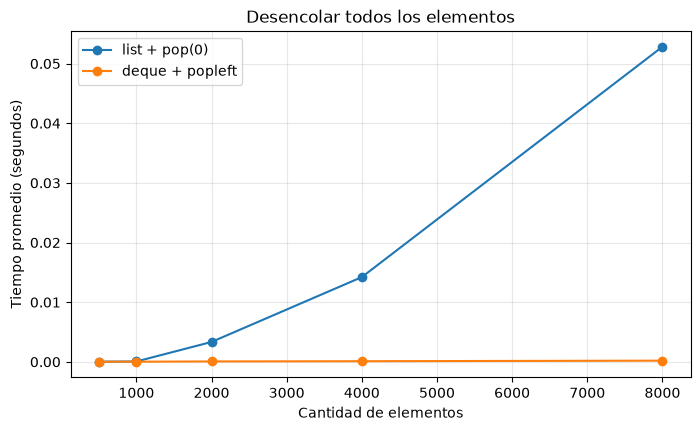

In [23]:
plt.figure(figsize=(8, 4.5))
plt.plot(tamanos, tiempos_lista, marker="o", label="list + pop(0)")
plt.plot(tamanos, tiempos_deque, marker="o", label="deque + popleft")
plt.xlabel("Cantidad de elementos")
plt.ylabel("Tiempo promedio (segundos)")
plt.title("Desencolar todos los elementos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Preguntas sobre la gráfica

1. ¿Cuál implementación crece más rápido?
la list + pop(0)
2. ¿La diferencia se nota desde tamaños pequeños o aparece más claramente al crecer `n`?
aparece mas claramente al crecer "n"
3. ¿Qué estructura usarías para una simulación con muchas operaciones FIFO?
la deque + popleft

## 7. Implementación con `collections.deque`

Python ofrece `deque`, una estructura diseñada para agregar y quitar elementos por ambos extremos.

Para colas FIFO usamos:

- `append(elemento)` para encolar;
- `popleft()` para desencolar.

In [24]:
class ColaDequeNotebook:
    """Implementación didáctica de una cola usando collections.deque."""

    def __init__(self):
        self._datos = deque()

    def encolar(self, elemento):
        self._datos.append(elemento)

    def desencolar(self):
        if self.esta_vacia():
            raise IndexError("no se puede desencolar de una cola vacía")
        return self._datos.popleft()

    def frente(self):
        if self.esta_vacia():
            raise IndexError("no se puede consultar el frente de una cola vacía")
        return self._datos[0]

    def esta_vacia(self):
        return len(self._datos) == 0

    def tamano(self):
        return len(self._datos)

In [25]:
cola_deque = ColaDequeNotebook()
for valor in ["A", "B", "C"]:
    cola_deque.encolar(valor)

print(cola_deque.desencolar())
print(cola_deque.desencolar())
print(cola_deque.frente())
print("Tamaño:", cola_deque.tamano())

A
B
C
Tamaño: 1


## 8. Misma interfaz, dos implementaciones

| Pregunta | `ColaLista` | `ColaDeque` |
| --- | --- | --- |
| ¿Es FIFO? | Sí | Sí |
| ¿Es clara para aprender? | Muy clara | Clara si conocemos `deque` |
| ¿Qué usa para desencolar? | `pop(0)` | `popleft()` |
| ¿Cuál conviene para muchas extracciones? | No suele ser ideal | Suele ser mejor |

La decisión depende de la operación que queremos hacer eficiente.

In [26]:
def probar_comportamiento_fifo(ClaseCola):
    cola = ClaseCola()
    cola.encolar("A")
    cola.encolar("B")
    cola.encolar("C")

    assert cola.desencolar() == "A"
    assert cola.desencolar() == "B"
    assert cola.desencolar() == "C"
    assert cola.esta_vacia()

for ClaseCola in [ColaListaNotebook, ColaDequeNotebook]:
    probar_comportamiento_fifo(ClaseCola)

print("La misma prueba funciona para ambas clases.")

La misma prueba funciona para ambas clases.


### Pregunta

¿Qué ventaja tiene escribir una prueba que funciona para varias implementaciones?
1. R = la ventaja que tiene es que a listas muy grandes es mas eficiente en tiempo y degamos que no pierdes generalidad

## 9. Usar el código del repositorio

Ahora importaremos las clases de `src/colas.py`.

Estas son las clases que usarás en la práctica y en las pruebas con `pytest`.

In [27]:
from src.colas import ColaLista, ColaDeque, cargar_cola, vaciar_cola

for ClaseCola in [ColaLista, ColaDeque]:
    cola = cargar_cola(ClaseCola(), [1, 2, 3, 4])
    print(ClaseCola.__name__, "->", vaciar_cola(cola))

ColaLista -> [1, 2, 3, 4]
ColaDeque -> [1, 2, 3, 4]


## 10. Pruebas con `pytest`

`pytest` permite organizar pruebas en archivos como:

```text
tests/test_colas.py
```

La idea es que las pruebas se puedan ejecutar todas juntas con:

```bash
pytest
```

In [ ]:
# Veamos el contenido de las pruebas principales.
pruebas_path = raiz / "tests" / "test_colas.py"
print(pruebas_path.read_text(encoding="utf-8")[:1800])

### `pytest.raises`

Cuando esperamos un error, no queremos que el notebook se detenga. Queremos verificar que el error correcto ocurre.

In [ ]:
import pytest

for ClaseCola in [ColaLista, ColaDeque]:
    cola = ClaseCola()
    with pytest.raises(IndexError):
        cola.desencolar()

print("Ambas implementaciones lanzan IndexError al desencolar vacías.")

### `pytest.mark.parametrize`

La parametrización permite usar la misma prueba para varias implementaciones.

Ese es uno de los beneficios de tener una interfaz común.

In [ ]:
ejemplo_parametrize = """
@pytest.mark.parametrize(\"ClaseCola\", [ColaLista, ColaDeque])
def test_frente_no_elimina(ClaseCola):
    cola = ClaseCola()
    cola.encolar(\"A\")
    cola.encolar(\"B\")
    assert cola.frente() == \"A\"
    assert cola.tamano() == 2
"""
print(ejemplo_parametrize)

## 11. Ejecutar las pruebas del proyecto

La siguiente celda ejecuta `pytest` desde la carpeta de la clase.

Si falla porque `pytest` no está instalado, revisa que hayas ejecutado:

```bash
pip install -r requirements.txt
```

In [ ]:
import subprocess

resultado = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=raiz,
    text=True,
    capture_output=True,
)

print(resultado.stdout)
if resultado.stderr:
    print(resultado.stderr)

assert resultado.returncode == 0, "Hay pruebas fallando. Revisa la salida de pytest."

## 12. Aplicaciones

Las colas aparecen cuando importa procesar en orden de llegada.

Ejemplos para Matemáticas Aplicadas:

- simulación de filas de espera;
- sistemas de eventos discretos;
- tareas pendientes en un algoritmo;
- procesamiento de mensajes;
- exploración por niveles en grafos.

La exploración por niveles se retomará más adelante. Por ahora basta notar que una cola permite atender primero lo que se descubrió primero.

In [ ]:
def simular_atencion(nombres):
    cola = ColaDeque()
    for nombre in nombres:
        cola.encolar(nombre)

    orden = []
    while not cola.esta_vacia():
        orden.append(cola.desencolar())
    return orden

simular_atencion(["Ana", "Beto", "Carla", "Diego"])

## 13. Ejercicios para completar

Responde en tu copia del notebook:

1. Escribe una secuencia de cinco operaciones con una cola y predice el resultado.
2. Explica por qué `frente()` no debe modificar la cola.
3. Escribe una prueba con `assert` para verificar que `tamano()` cambia correctamente.
4. Agrega una prueba propia en `tests/test_colas.py`.
5. Explica cuándo usarías `ColaDeque` en lugar de `ColaLista`.

In [ ]:
# Espacio de trabajo: escribe aquí una secuencia propia.
# Mantén esta celda ejecutable.
cola_personal = ColaDeque()

# TODO alumno: agrega operaciones encolar/desencolar/frente.
cola_personal.encolar("ejemplo")

print("Frente:", cola_personal.frente())
print("Tamaño:", cola_personal.tamano())

## 14. Reto opcional

Diseña una función `atender_hasta(cola, limite)` que quite como máximo `limite` elementos de una cola y regrese la lista de elementos atendidos.

Preguntas:

- ¿Qué debe ocurrir si `limite` es mayor que el tamaño de la cola?
- ¿Qué debe ocurrir si `limite` es cero?
- ¿Conviene modificar la cola original o trabajar con una copia?

In [ ]:
def atender_hasta(cola, limite):
    """Reto opcional: atiende como máximo limite elementos de una cola."""
    if limite < 0:
        raise ValueError("limite no puede ser negativo")

    atendidos = []
    while limite > 0 and not cola.esta_vacia():
        atendidos.append(cola.desencolar())
        limite -= 1
    return atendidos

cola_reto = cargar_cola(ColaDeque(), ["A", "B", "C", "D"])
atender_hasta(cola_reto, 2)

## 15. Reflexión final

Responde en tu `resumen.md`:

1. ¿Cuál es la diferencia más importante entre una pila y una cola?
2. ¿Cuál implementación fue más clara para ti?
3. ¿Cuál implementación parece más eficiente para muchas extracciones?
4. ¿Qué aprendiste al usar `pytest` con dos implementaciones?
5. ¿Dónde usarías una cola en un problema de Matemáticas Aplicadas?
6. ¿Qué duda te queda?